In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt


In [ ]:
# 1.2 Load Movielens dataset (example: 100k dataset)
# Replace 'ratings.csv' with the actual path to your dataset
ratings = pd.read_csv('MovieLens/ratings.csv')

# Preprocess data: Keep only 'userId', 'movieId', and 'rating' columns
ratings = ratings[['userId', 'movieId', 'rating']]
ratings.columns = ['user_id', 'item_id', 'rating']



In [21]:

# 1.3 Train-test split

if False:
    # Use part of the ratings dataset for training, for faster training
    # (optional, can be removed for full dataset training)
    ratings = ratings.sample(frac=0.5, random_state=42).reset_index(drop=True)

# Split data into train and test sets
# save some data for evaluation
# Split the data into train, test, and evaluation sets
traintest_data, eval_data = train_test_split(ratings, test_size=0.5) #, random_state=42)
train_data, test_data = train_test_split(traintest_data, test_size=0.2) #, random_state=42)

print(test_data.head(20))

       user_id  item_id  rating
32501      221     5008     4.0
9918        64    26504     3.5
16341      105     3623     4.0
31660      219     1704     4.0
58146      381      648     3.0
46912      307     1204     3.5
6249        42     3755     5.0
4610        28    40629     2.0
65946      425      593     4.0
67051      432    85885     4.5
91318      592      161     4.0
16024      104     1947     4.0
79460      493     2924     4.0
5703        41     1961     4.0
80582      509     8643     2.5
20320      134      316     4.0
95713      600     5943     3.0
9353        63    32587     5.0
55787      368     3370     3.0
4811        29     3578     5.0


In [20]:
# 1.4 Map user and item IDs to indices

# Extract unique users and items
n_users = ratings['user_id'].nunique()
n_items = ratings['item_id'].nunique()
print(f"Number of users: {n_users}, Number of items: {n_items}")
# Create user-item interaction matrix
user_id_map = {user_id: idx for idx, user_id in enumerate(ratings['user_id'].unique())}
item_id_map = {item_id: idx for idx, item_id in enumerate(ratings['item_id'].unique())}

# Map user and item IDs to indices
train_data['user_idx'] = train_data['user_id'].map(user_id_map)
train_data['item_idx'] = train_data['item_id'].map(item_id_map)
test_data['user_idx'] = test_data['user_id'].map(user_id_map)
test_data['item_idx'] = test_data['item_id'].map(item_id_map)
eval_data['user_idx'] = eval_data['user_id'].map(user_id_map)
eval_data['item_idx'] = eval_data['item_id'].map(item_id_map)

train_data.head(10)

Number of users: 610, Number of items: 9724


,user_id,item_id,rating,user_idx,item_idx
17554,111,48520,4.0,110,3793
61142,399,3114,4.0,398,735
59145,385,1298,4.0,384,90
69016,448,2375,3.0,447,1605
19730,129,2628,3.5,128,171
65002,415,344,3.0,414,470
49087,318,1260,4.0,317,1107
61563,407,5445,5.0,406,758
87187,562,2804,1.0,561,1652
96180,603,314,3.0,602,595


In [22]:
# 1.5 Implementation of Matrix Factorization with SGD


class MatrixFactorization:
    def __init__(self, n_factors=50, learning_rate=0.01, reg_param=0.01, n_epochs=20, use_bias=True, verbose=True):
        """
        Initialize the Matrix Factorization model with optional bias terms.

        Parameters:
        - n_factors: Number of latent factors.
        - learning_rate: Learning rate for SGD.
        - reg_param: Regularization parameter.
        - n_epochs: Number of training epochs.
        - use_bias: Boolean flag to enable or disable bias terms.
        - verbose: Whether to print RMSE at each epoch.
        """
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.reg_param = reg_param
        self.n_epochs = n_epochs
        self.use_bias = use_bias
        self.verbose = verbose
        self.user_factors = None
        self.item_factors = None
        self.user_bias = None
        self.item_bias = None
        self.global_mean = None
        self.errors = []  # List to store RMSE at each epoch
        self.n_users = None
        self.n_items = None 
        self.user_id_map = None
        self.item_id_map = None

    def _initialize_factors(self, n_users, n_items, ratings):
        """
        Initialize user and item latent factors, biases, and global mean.
        """
        self.user_factors = np.random.normal(scale=1.0 / self.n_factors, size=(n_users, self.n_factors))
        self.item_factors = np.random.normal(scale=1.0 / self.n_factors, size=(n_items, self.n_factors))
        if self.use_bias:
            self.user_bias = np.zeros(n_users)
            self.item_bias = np.zeros(n_items)  
            self.global_mean = ratings['rating'].mean()

    def _predict(self, user_id, item_id):
        """
        Predict the rating for a given user and item.
        """
        prediction = np.dot(self.user_factors[user_id], self.item_factors[item_id])
        if self.use_bias:
            prediction += self.global_mean + self.user_bias[user_id] + self.item_bias[item_id]
        return prediction

    def _update_factors(self, user_id, item_id, rating):
        """
        Update user and item latent factors, biases, and global mean using SGD.
        """
        # Compute the prediction error
        prediction = self._predict(user_id, item_id)
        error = rating - prediction

        # Update user and item factors
        self.user_factors[user_id] += self.learning_rate * (error * self.item_factors[item_id] - self.reg_param * self.user_factors[user_id])
        self.item_factors[item_id] += self.learning_rate * (error * self.user_factors[user_id] - self.reg_param * self.item_factors[item_id])

        # Update user and item biases if bias is enabled
        if self.use_bias:
            self.user_bias[user_id] += self.learning_rate * (error - self.reg_param * self.user_bias[user_id])
            self.item_bias[item_id] += self.learning_rate * (error - self.reg_param * self.item_bias[item_id])


    def build_maps(self, data):

        # Extract unique users and items
        self.n_users = data['user_id'].nunique()
        self.n_items = data['item_id'].nunique()
        print(f"Number of users: {self.n_users}, Number of items: {self.n_items}")
        # Create mappings from user/item IDs to indices
        self.user_id_map = {user_id: idx for idx, user_id in enumerate(data['user_id'].unique())}
        self.item_id_map = {item_id: idx for idx, item_id in enumerate(data['item_id'].unique())}



    def fit(self, train_data, test_data, convergence_threshold=1e-4):
        """
        Train the Matrix Factorization model.

        Parameters:
        - train_data: DataFrame with columns ['user_id', 'item_id', 'rating'] for training.
        - test_data: DataFrame with columns ['user_id', 'item_id', 'rating'] for testing.
        """
        # joint train and test data to build maps
        if (self.n_users is None) or (self.n_items is None):
            print("ERROR: run build_maps(all_ratings) before fit()")
            #self.build_maps(pd.concat([train_data, test_data], ignore_index=True))
            return

        # Map user and item IDs to indices
        train_data['user_idx'] = train_data['user_id'].map(self.user_id_map)
        train_data['item_idx'] = train_data['item_id'].map(self.item_id_map)
        test_data['user_idx'] = test_data['user_id'].map(self.user_id_map)
        test_data['item_idx'] = test_data['item_id'].map(self.item_id_map)

        # Initialize latent factors
        self._initialize_factors(self.n_users, self.n_items, train_data)

        # Training loop
        for epoch in range(1, self.n_epochs + 1):
            # Shuffle training data for SGD
            train_data_shuffled = train_data.sample(frac=1).reset_index(drop=True)

            # Update latent factors using SGD
            for _, row in train_data_shuffled.iterrows():
                user_idx = int(row['user_idx'])  # Ensure user_idx is an integer
                item_idx = int(row['item_idx'])  # Ensure item_idx is an integer
                rating = row['rating']  # Rating can remain as float
                self._update_factors(user_idx, item_idx, rating)

            # Compute RMSE on test data
            test_predictions = [
                self._predict(int(user_idx), int(item_idx))
                for _, row in test_data.iterrows()
                for user_idx, item_idx in [(row['user_idx'], row['item_idx'])]
            ]
            test_ratings = test_data['rating'].values
            rmse = np.sqrt(mean_squared_error(test_ratings, test_predictions))
            # previous error
            prev_rmse = self.errors[-1] if self.errors else None
            # Store RMSE for this epoch
            self.errors.append(rmse)  # Store RMSE for this epoch
            # Check for convergence
            if prev_rmse is not None and abs(prev_rmse - rmse)/abs(rmse) < convergence_threshold:
                print(f"Converged at epoch {epoch}.")
                break
            # Check if error is increasing
            if prev_rmse is not None and rmse > prev_rmse:
                print(f"Error increased at epoch {epoch}. Stopping training.")
                break
            if self.verbose:
                print(f"Epoch {epoch}/{self.n_epochs} - Test RMSE: {rmse:.4f}")

    def get_errors(self):
        """
        Return the list of RMSE values at each epoch.
        """
        return self.errors

    def calculate_model_parameters(self):
        """
        Calculate the total number of parameters in the model.
        """
        n_users = self.user_factors.shape[0]
        n_items = self.item_factors.shape[0]

        # Parameters: user_factors, item_factors, user_bias, item_bias, global_mean
        total_params = (
            n_users * self.n_factors  # User latent factors
            + n_items * self.n_factors  # Item latent factors
            + (n_users if self.use_bias else 0)  # User biases
            + (n_items if self.use_bias else 0)  # Item biases
            + (1 if self.use_bias else 0)  # Global mean
        )
        return total_params

    def predict(self, user_id, item_id): #, user_id_map, item_id_map):
        """
        Predict the rating for a given user and item.

        Parameters:
        - user_id: User ID.
        - item_id: Item ID.
        - user_id_map: Mapping from user IDs to indices.
        - item_id_map: Mapping from item IDs to indices.
        """
        user_idx = self.user_id_map[user_id]
        item_idx = self.item_id_map[item_id]
        return self._predict(user_idx, item_idx)




In [27]:
# 1.6 Train the model

# Initialize and train the Matrix Factorization model
mf = MatrixFactorization(n_factors=5, learning_rate=0.01, reg_param=0.01, n_epochs=20, use_bias=False, verbose=True)
mf.build_maps(ratings)

# Train the model
mf.fit(train_data, test_data, convergence_threshold=1e-2)

# Calculate the number of parameters in the model
num_params = mf.calculate_model_parameters()
print(f"Total number of parameters in the model: {num_params}")


Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.6501
Epoch 2/20 - Test RMSE: 3.3528
Epoch 3/20 - Test RMSE: 2.3846
Epoch 4/20 - Test RMSE: 1.9296
Epoch 5/20 - Test RMSE: 1.7119
Epoch 6/20 - Test RMSE: 1.5904
Epoch 7/20 - Test RMSE: 1.5146
Epoch 8/20 - Test RMSE: 1.4639
Epoch 9/20 - Test RMSE: 1.4307
Epoch 10/20 - Test RMSE: 1.4067
Epoch 11/20 - Test RMSE: 1.3868
Epoch 12/20 - Test RMSE: 1.3724
Converged at epoch 13.
Total number of parameters in the model: 51670


In [28]:
# Evaluate the model on the evaluation set
eval_data.describe()

,user_id,item_id,rating
count,50418.000000,50418.000000,50418.000000
mean,326.030822,19520.464398,3.500238
std,182.596323,35552.574944,1.045819
min,1.000000,1.000000,0.500000
25%,177.000000,1199.000000,3.000000
50%,325.000000,3006.000000,3.500000
75%,477.000000,8361.000000,4.000000
max,610.000000,193609.000000,5.000000


In [29]:
# TEST
# mapping of items to indices
print(mf.item_id_map.keys().__len__())
keys = list(mf.item_id_map.keys())
print(keys[0:10])

for i in eval_data['item_id']:
    if i not in keys:
        print("Item not found in item_id_map: ", i)
        break

9724
[1, 3, 6, 47, 50, 70, 101, 110, 151, 157]


In [32]:
# 1.7 Prediction

# Example prediction
# Select one example user and item from the dataset
# Ensure that the user and item IDs exist in the dataset
rating_index = 200  # Change this to select a different rating

data = [1,10,20,30,40,50,60,80,100,110,1000]

for rating_index in data:
    rating_row = ratings.iloc[rating_index]
    user_id = rating_row['user_id'].astype(int)  # Ensure user_id is an integer
    item_id = rating_row['item_id'].astype(int)  # Ensure item_id is an integer
    print(f"User ID: {user_id}, Item ID: {item_id}")


    predicted_rating = mf.predict(user_id, item_id) 
    print(f"    Predicted rating for user {user_id} and item {item_id}: {predicted_rating:.2f}")

    # Actual rating for comparison
    actual_rating = rating_row['rating']
    error = abs(predicted_rating - actual_rating)
    print(f"    Actual rating for user {user_id} and item {item_id}: {actual_rating:.2f}, error: {error:.2f}")

User ID: 1, Item ID: 3
    Predicted rating for user 1 and item 3: 3.85
    Actual rating for user 1 and item 3: 4.00, error: 0.15
User ID: 1, Item ID: 163
    Predicted rating for user 1 and item 163: 3.78
    Actual rating for user 1 and item 163: 5.00, error: 1.22
User ID: 1, Item ID: 356
    Predicted rating for user 1 and item 356: 5.26
    Actual rating for user 1 and item 356: 4.00, error: 1.26
User ID: 1, Item ID: 552
    Predicted rating for user 1 and item 552: 3.86
    Actual rating for user 1 and item 552: 4.00, error: 0.14
User ID: 1, Item ID: 733
    Predicted rating for user 1 and item 733: 4.43
    Actual rating for user 1 and item 733: 4.00, error: 0.43
User ID: 1, Item ID: 1023
    Predicted rating for user 1 and item 1023: 4.55
    Actual rating for user 1 and item 1023: 5.00, error: 0.45
User ID: 1, Item ID: 1073
    Predicted rating for user 1 and item 1073: 4.37
    Actual rating for user 1 and item 1073: 5.00, error: 0.63
User ID: 1, Item ID: 1226
    Predicted r

In [37]:
# 1.8 Evaluate the model on the evaluation set

# Retrieve RMSE values
errors = mf.get_errors()
print("RMSE per epoch:", errors)


# Compute RMSE on test data
test_predictions = [
    mf.predict(user_id, item_id)
    for _, row in eval_data.iterrows()
    for user_id, item_id in [(row['user_id'], row['item_id'])]
]
test_ratings = eval_data['rating'].values
rmse = np.sqrt(mean_squared_error(test_ratings, test_predictions))

# Print RMSE
print("RMSE on evaluation data: ", rmse)





RMSE per epoch: [3.098603054422551, 1.8595517044519163, 1.5647063413561835, 1.4525924788275928, 1.396000124026157, 1.3673788640011206, 1.3504357750723468]
RMSE on evaluation data:  1.3301698912604598


In [38]:
# Predict values for all data in ratings, and plot the distribution of errors
def predict_errors_plot(input_data, model):
    """
    Predict ratings for the input data using the trained model.
    """
    predictions = input_data.copy()
    predictions['predicted_rating'] = predictions.apply(lambda row: model.predict(row['user_id'], row['item_id']), axis=1)

    # Calculate the error
    predictions['error'] = predictions['predicted_rating'] - predictions['rating']

    # Calculate RMSE for the entire dataset
    rmse_all = np.sqrt(mean_squared_error(predictions['rating'], predictions['predicted_rating']))
    print(f"RMSE error: {rmse_all:.4f}")

    # Plot the distribution of predicted ratings
    fig1 = plt.figure(figsize=(11, 3))
    
    plt.subplot(1, 2, 1)
    
    plt.hist(predictions['predicted_rating'], bins=50, alpha=0.5, color='green')

    # Plot the distribution of actual ratings
    plt.hist(predictions['rating'], bins=50, alpha=0.5, color='red')
    plt.title('Distribution of Actual and Predicted Ratings')
    plt.xlabel('Rating')
    plt.ylabel('Frequency')
    plt.grid()
    plt.legend(['Predicted Ratings', 'Actual Ratings'])
    plt.subplot(1, 2, 2)
    
    # Plot the distribution of errors
    #plt.figure(figsize=(8, 3))
    plt.hist(predictions['error'], bins=50, alpha=0.7, color='purple')
    plt.title('Distribution of Prediction Errors, {RMSE: %.4f}' % rmse_all)
    plt.axvline(rmse_all, color='black', linestyle='dashed', linewidth=1)
    plt.axvline(-rmse_all, color='black', linestyle='dashed', linewidth=1)
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()
    
    return predictions


RMSE error: 1.3302


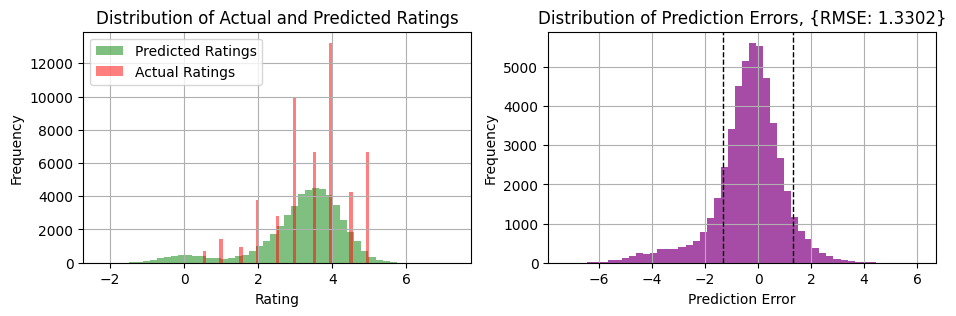

RMSE error: 0.7633


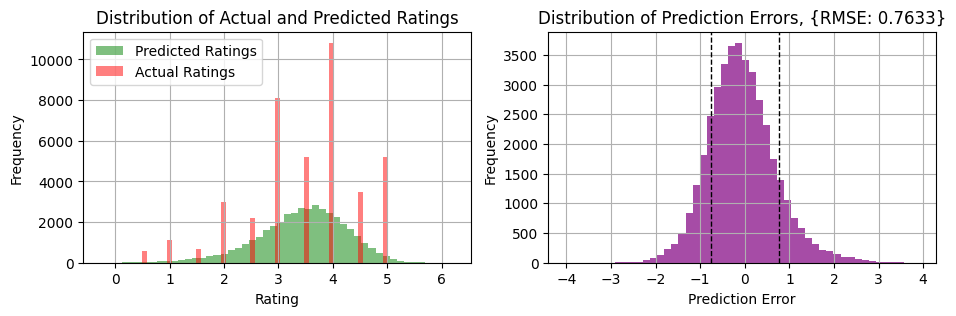

RMSE error: 1.3460


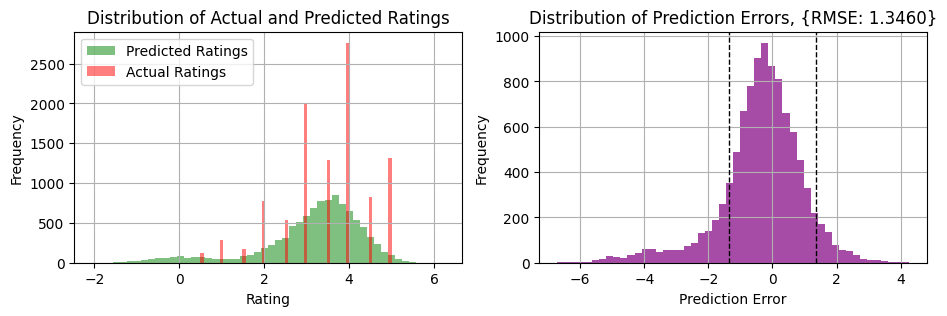

In [39]:
# 1.9 Plot predicted ratings and errors
pre = predict_errors_plot(eval_data, mf)

pre = predict_errors_plot(train_data, mf)

pre = predict_errors_plot(test_data, mf)


### 2. Testing models and parameters


 *******    Training with 1 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.6631
Epoch 2/20 - Test RMSE: 2.9332
Epoch 3/20 - Test RMSE: 2.1653
Epoch 4/20 - Test RMSE: 1.8503
Epoch 5/20 - Test RMSE: 1.6920
Epoch 6/20 - Test RMSE: 1.6058
Epoch 7/20 - Test RMSE: 1.5502
Epoch 8/20 - Test RMSE: 1.5095
Epoch 9/20 - Test RMSE: 1.4800
Epoch 10/20 - Test RMSE: 1.4641
Epoch 11/20 - Test RMSE: 1.4504
Epoch 12/20 - Test RMSE: 1.4358
Epoch 13/20 - Test RMSE: 1.4300
Epoch 14/20 - Test RMSE: 1.4222
Epoch 15/20 - Test RMSE: 1.4168
Epoch 16/20 - Test RMSE: 1.4161
Epoch 17/20 - Test RMSE: 1.4124
Epoch 18/20 - Test RMSE: 1.4110
Epoch 19/20 - Test RMSE: 1.4066
Epoch 20/20 - Test RMSE: 1.4051
RMSE error: 1.4158


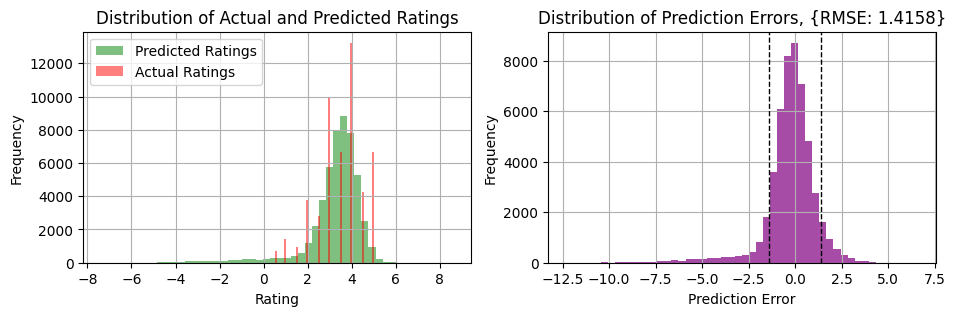

Total number of parameters in the model: 10334

 *******    Training with 2 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.5128
Epoch 2/20 - Test RMSE: 2.1120
Epoch 3/20 - Test RMSE: 1.6962
Epoch 4/20 - Test RMSE: 1.5393
Epoch 5/20 - Test RMSE: 1.4612
Epoch 6/20 - Test RMSE: 1.4149
Epoch 7/20 - Test RMSE: 1.3884
Epoch 8/20 - Test RMSE: 1.3720
Epoch 9/20 - Test RMSE: 1.3566
Epoch 10/20 - Test RMSE: 1.3471
Epoch 11/20 - Test RMSE: 1.3417
Epoch 12/20 - Test RMSE: 1.3383
Epoch 13/20 - Test RMSE: 1.3335
Epoch 14/20 - Test RMSE: 1.3333
Epoch 15/20 - Test RMSE: 1.3277
Epoch 16/20 - Test RMSE: 1.3269
Error increased at epoch 17. Stopping training.
RMSE error: 1.3273


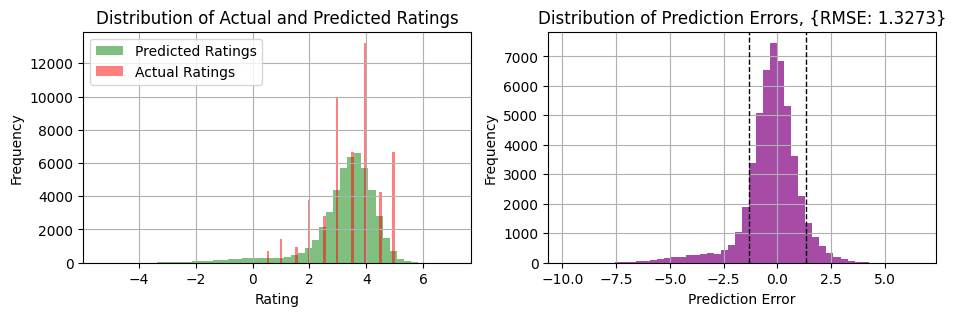

Total number of parameters in the model: 20668

 *******    Training with 5 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.4537
Epoch 2/20 - Test RMSE: 1.9724
Epoch 3/20 - Test RMSE: 1.6013
Epoch 4/20 - Test RMSE: 1.4670
Epoch 5/20 - Test RMSE: 1.4046
Epoch 6/20 - Test RMSE: 1.3720
Epoch 7/20 - Test RMSE: 1.3502
Epoch 8/20 - Test RMSE: 1.3385
Epoch 9/20 - Test RMSE: 1.3340
Epoch 10/20 - Test RMSE: 1.3305
Epoch 11/20 - Test RMSE: 1.3301
Epoch 12/20 - Test RMSE: 1.3284
Epoch 13/20 - Test RMSE: 1.3265
Error increased at epoch 14. Stopping training.
RMSE error: 1.3197


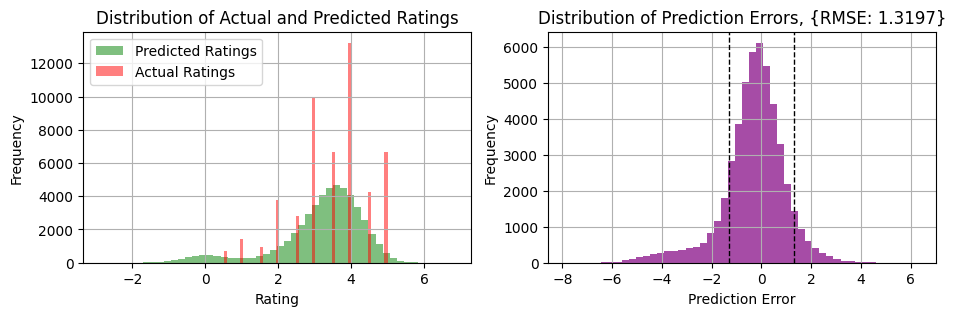

Total number of parameters in the model: 51670

 *******    Training with 10 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.2312
Epoch 2/20 - Test RMSE: 1.8672
Epoch 3/20 - Test RMSE: 1.5511
Epoch 4/20 - Test RMSE: 1.4311
Epoch 5/20 - Test RMSE: 1.3780
Epoch 6/20 - Test RMSE: 1.3479
Epoch 7/20 - Test RMSE: 1.3326
Epoch 8/20 - Test RMSE: 1.3275
Epoch 9/20 - Test RMSE: 1.3230
Epoch 10/20 - Test RMSE: 1.3204
Error increased at epoch 11. Stopping training.
RMSE error: 1.3173


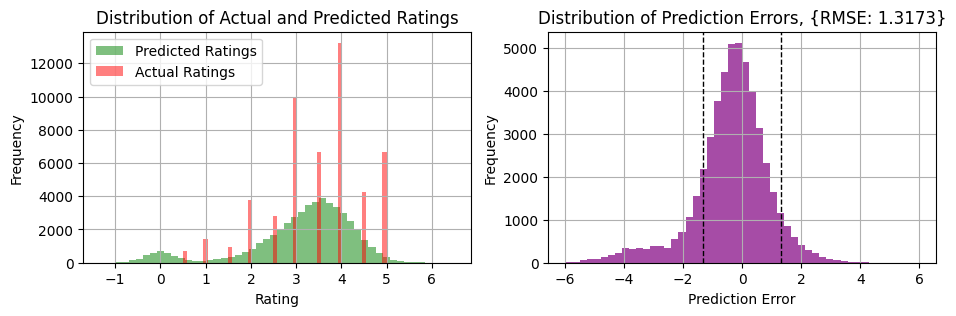

Total number of parameters in the model: 103340

 *******    Training with 30 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.5587
Epoch 2/20 - Test RMSE: 2.0009
Epoch 3/20 - Test RMSE: 1.5791
Epoch 4/20 - Test RMSE: 1.4354
Epoch 5/20 - Test RMSE: 1.3674
Epoch 6/20 - Test RMSE: 1.3347
Epoch 7/20 - Test RMSE: 1.3141
Epoch 8/20 - Test RMSE: 1.3034
Epoch 9/20 - Test RMSE: 1.2975
Epoch 10/20 - Test RMSE: 1.2965
Error increased at epoch 11. Stopping training.
RMSE error: 1.2861


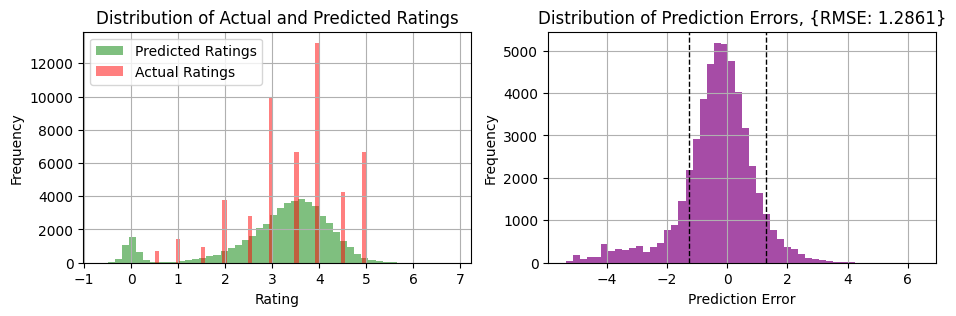

Total number of parameters in the model: 310020

 *******    Training with 50 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 3.5885
Epoch 2/20 - Test RMSE: 2.0334
Epoch 3/20 - Test RMSE: 1.5894
Epoch 4/20 - Test RMSE: 1.4400
Epoch 5/20 - Test RMSE: 1.3660
Epoch 6/20 - Test RMSE: 1.3308
Epoch 7/20 - Test RMSE: 1.3110
Epoch 8/20 - Test RMSE: 1.2987
Epoch 9/20 - Test RMSE: 1.2929
Epoch 10/20 - Test RMSE: 1.2863
Epoch 11/20 - Test RMSE: 1.2859
Epoch 12/20 - Test RMSE: 1.2833
Error increased at epoch 13. Stopping training.
RMSE error: 1.2739


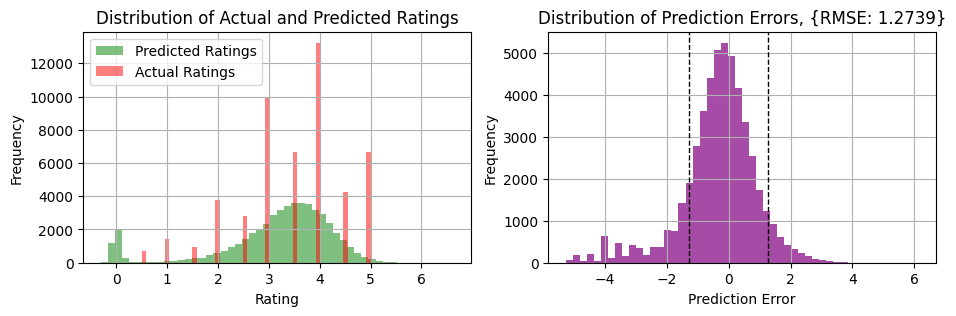

Total number of parameters in the model: 516700


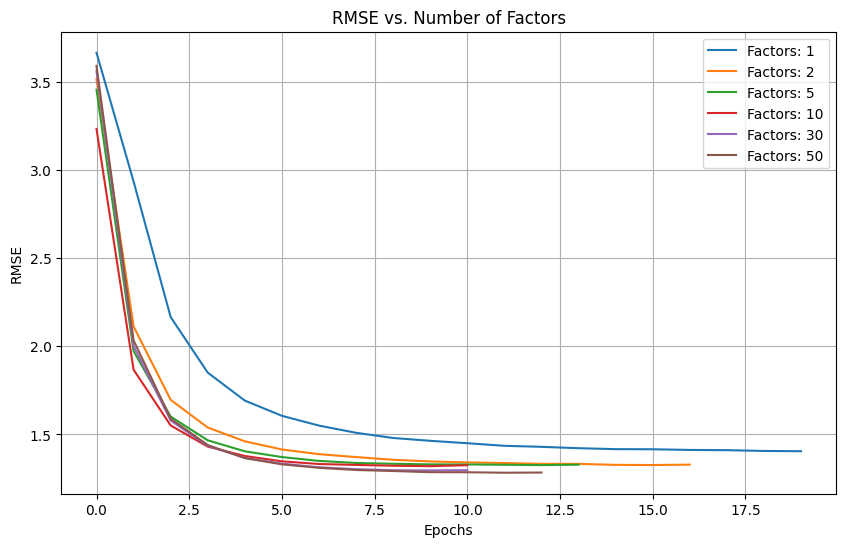

In [40]:
# 2.1 Plot RMSE vs. number of factors

factors_list = [1, 2, 5, 10, 30, 50]

errors_list = []
num_params_list = []

# Train and evaluate the model with different numbers of factors
for n_factors in factors_list:
    
    print(f"\n *******    Training with {n_factors} factors...")
    
    mf = MatrixFactorization(n_factors=n_factors, learning_rate=0.02, reg_param=0.01, n_epochs=20, use_bias=False, verbose=True)
    mf.build_maps(ratings)
    mf.fit(train_data, test_data)
    errors_list.append(mf.get_errors())

    # Evaluate the model on the evaluation set
    predict_errors_plot(eval_data, mf)
    
    # Calculate the number of parameters in the model
    num_params = mf.calculate_model_parameters()
    print(f"Total number of parameters in the model: {num_params}")    
    num_params_list.append(num_params)

# Plot RMSE vs. number of factors
plt.figure(figsize=(10, 6))
for i, n_factors in enumerate(factors_list):
    plt.plot(errors_list[i], label=f'Factors: {n_factors}')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('RMSE vs. Number of Factors')
plt.legend()
plt.grid()
plt.show()



 *******    Training with 1 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9565
Epoch 2/20 - Test RMSE: 0.9234
Epoch 3/20 - Test RMSE: 0.9095
Epoch 4/20 - Test RMSE: 0.9044
Epoch 5/20 - Test RMSE: 0.8996
Epoch 6/20 - Test RMSE: 0.8982
Epoch 7/20 - Test RMSE: 0.8979
Epoch 8/20 - Test RMSE: 0.8949
Error increased at epoch 9. Stopping training.
RMSE error: 0.8998


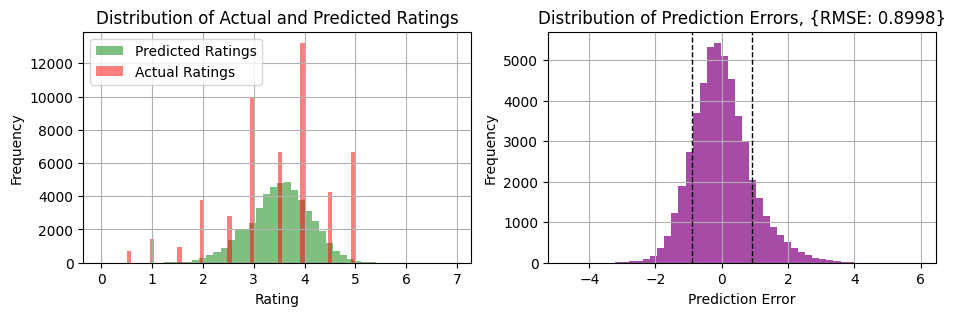

Total number of parameters in the model: 20669

 *******    Training with 2 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9331
Epoch 2/20 - Test RMSE: 0.9129
Epoch 3/20 - Test RMSE: 0.9038
Epoch 4/20 - Test RMSE: 0.8998
Epoch 5/20 - Test RMSE: 0.8980
Epoch 6/20 - Test RMSE: 0.8979
Converged at epoch 7.
RMSE error: 0.9002


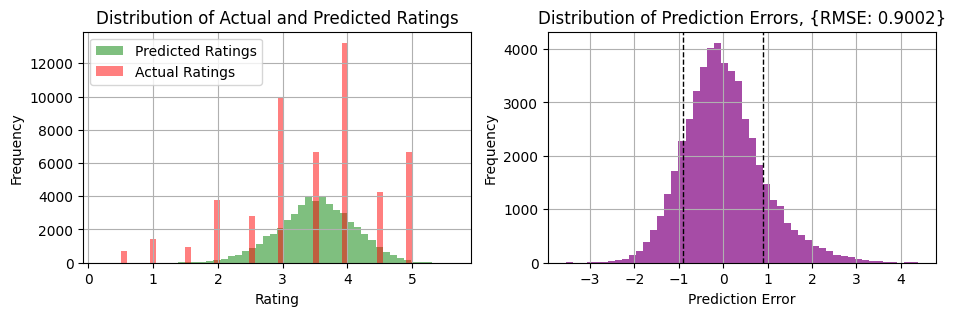

Total number of parameters in the model: 31003

 *******    Training with 5 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9141
Epoch 2/20 - Test RMSE: 0.9016
Epoch 3/20 - Test RMSE: 0.8948
Epoch 4/20 - Test RMSE: 0.8913
Epoch 5/20 - Test RMSE: 0.8907
Error increased at epoch 6. Stopping training.
RMSE error: 0.8931


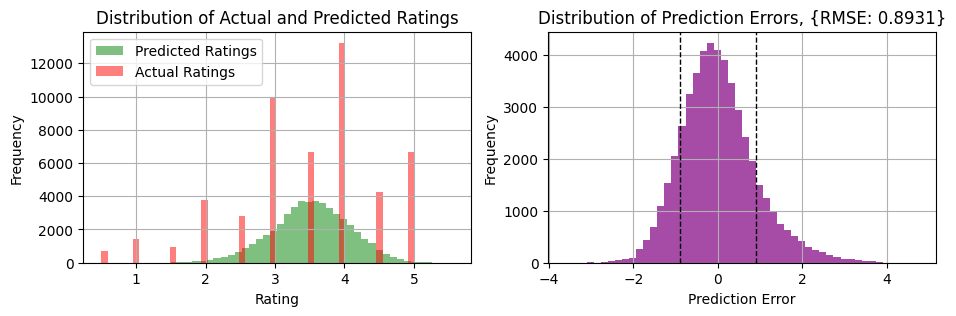

Total number of parameters in the model: 62005

 *******    Training with 10 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9118
Epoch 2/20 - Test RMSE: 0.8982
Epoch 3/20 - Test RMSE: 0.8913
Epoch 4/20 - Test RMSE: 0.8883
Epoch 5/20 - Test RMSE: 0.8871
Converged at epoch 6.
RMSE error: 0.8904


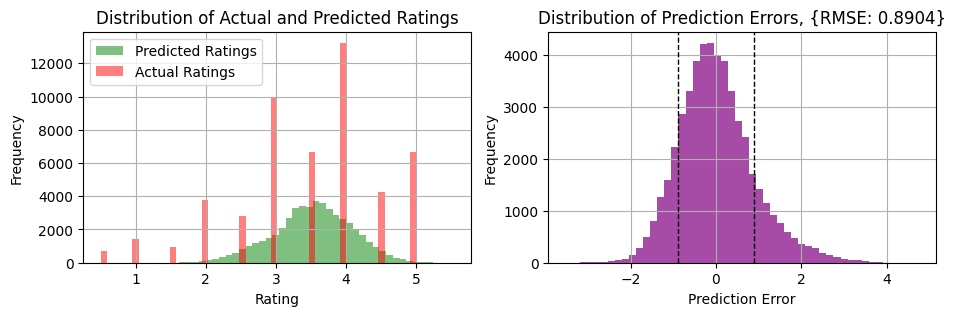

Total number of parameters in the model: 113675

 *******    Training with 30 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9110
Epoch 2/20 - Test RMSE: 0.8977
Epoch 3/20 - Test RMSE: 0.8910
Epoch 4/20 - Test RMSE: 0.8868
Epoch 5/20 - Test RMSE: 0.8842
Epoch 6/20 - Test RMSE: 0.8840
Epoch 7/20 - Test RMSE: 0.8830
Converged at epoch 8.
RMSE error: 0.8840


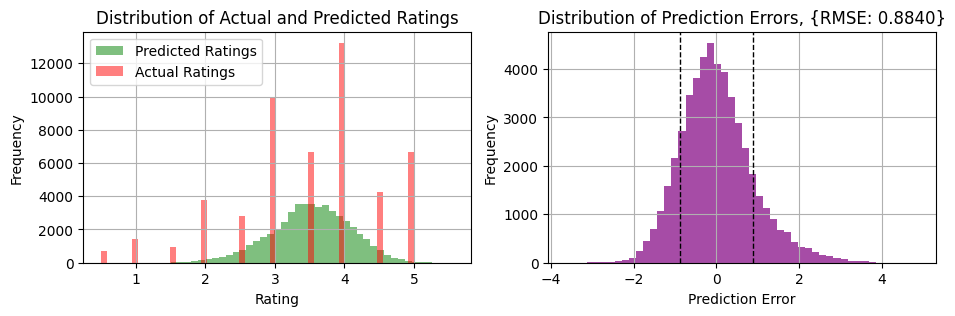

Total number of parameters in the model: 320355

 *******    Training with 50 factors...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9109
Epoch 2/20 - Test RMSE: 0.8975
Epoch 3/20 - Test RMSE: 0.8904
Epoch 4/20 - Test RMSE: 0.8883
Epoch 5/20 - Test RMSE: 0.8838
Error increased at epoch 6. Stopping training.
RMSE error: 0.8863


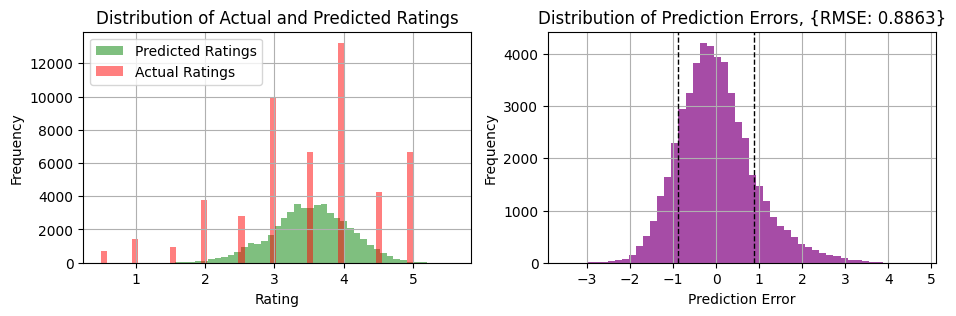

Total number of parameters in the model: 527035


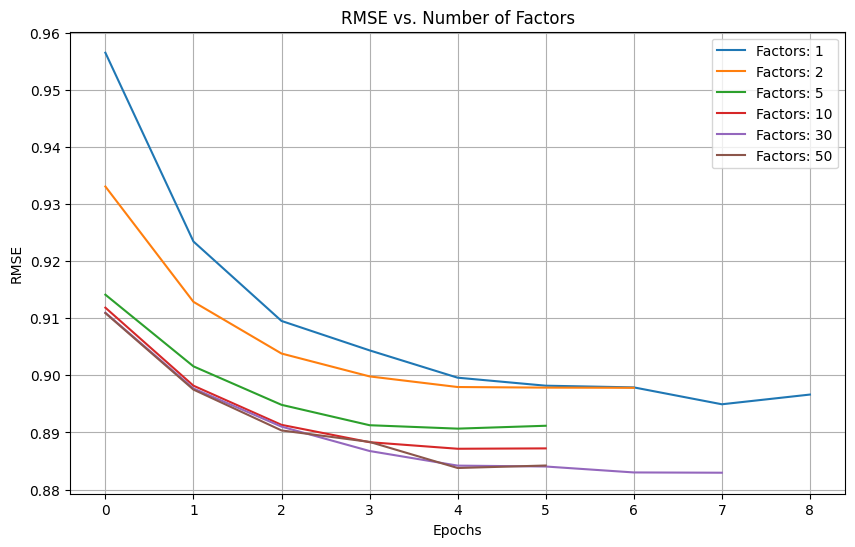

In [41]:
# 2.2. Plot RMSE vs. number of parameters, use Biased model

factors_list = [1, 2, 5, 10, 30, 50]

errors_list = []
num_params_list = []

# Train and evaluate the model with different numbers of factors
for n_factors in factors_list:
    
    print(f"\n *******    Training with {n_factors} factors...")
    
    mf = MatrixFactorization(n_factors=n_factors, learning_rate=0.02, reg_param=0.01, n_epochs=20, use_bias=True, verbose=True)
    mf.build_maps(ratings)
    mf.fit(train_data, test_data)
    errors_list.append(mf.get_errors())

    # Evaluate the model on the evaluation set
    predict_errors_plot(eval_data, mf)
    
    # Calculate the number of parameters in the model
    num_params = mf.calculate_model_parameters()
    print(f"Total number of parameters in the model: {num_params}")    
    num_params_list.append(num_params)

# Plot RMSE vs. number of factors
plt.figure(figsize=(10, 6))
for i, n_factors in enumerate(factors_list):
    plt.plot(errors_list[i], label=f'Factors: {n_factors}')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('RMSE vs. Number of Factors')
plt.legend()
plt.grid()
plt.show()




 *******    Training with 0.002 learning rate...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9831
Epoch 2/20 - Test RMSE: 0.9603
Epoch 3/20 - Test RMSE: 0.9464
Epoch 4/20 - Test RMSE: 0.9367
Epoch 5/20 - Test RMSE: 0.9295
Epoch 6/20 - Test RMSE: 0.9240
Epoch 7/20 - Test RMSE: 0.9195
Epoch 8/20 - Test RMSE: 0.9157
Epoch 9/20 - Test RMSE: 0.9127
Epoch 10/20 - Test RMSE: 0.9100
Epoch 11/20 - Test RMSE: 0.9077
Epoch 12/20 - Test RMSE: 0.9057
Epoch 13/20 - Test RMSE: 0.9040
Epoch 14/20 - Test RMSE: 0.9024
Epoch 15/20 - Test RMSE: 0.9009
Epoch 16/20 - Test RMSE: 0.8996
Epoch 17/20 - Test RMSE: 0.8984
Epoch 18/20 - Test RMSE: 0.8974
Epoch 19/20 - Test RMSE: 0.8963
Epoch 20/20 - Test RMSE: 0.8954
RMSE error: 0.8983


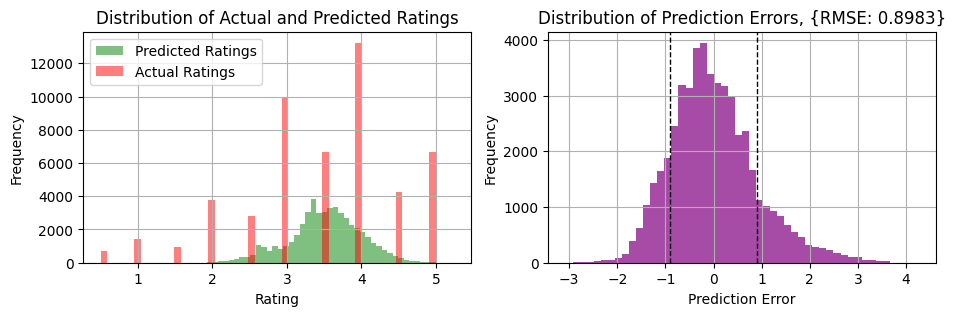

Total number of parameters in the model: 320355

 *******    Training with 0.005 learning rate...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9529
Epoch 2/20 - Test RMSE: 0.9297
Epoch 3/20 - Test RMSE: 0.9177
Epoch 4/20 - Test RMSE: 0.9101
Epoch 5/20 - Test RMSE: 0.9046
Epoch 6/20 - Test RMSE: 0.9009
Epoch 7/20 - Test RMSE: 0.8980
Epoch 8/20 - Test RMSE: 0.8956
Epoch 9/20 - Test RMSE: 0.8934
Epoch 10/20 - Test RMSE: 0.8920
Epoch 11/20 - Test RMSE: 0.8905
Epoch 12/20 - Test RMSE: 0.8892
Epoch 13/20 - Test RMSE: 0.8883
Epoch 14/20 - Test RMSE: 0.8876
Epoch 15/20 - Test RMSE: 0.8865
Epoch 16/20 - Test RMSE: 0.8858
Epoch 17/20 - Test RMSE: 0.8852
Epoch 18/20 - Test RMSE: 0.8849
Epoch 19/20 - Test RMSE: 0.8843
Epoch 20/20 - Test RMSE: 0.8839
RMSE error: 0.8863


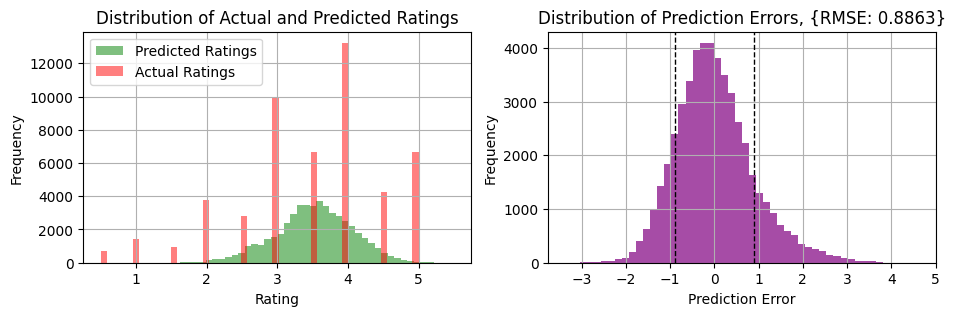

Total number of parameters in the model: 320355

 *******    Training with 0.01 learning rate...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9302
Epoch 2/20 - Test RMSE: 0.9102
Epoch 3/20 - Test RMSE: 0.9013
Epoch 4/20 - Test RMSE: 0.8969
Epoch 5/20 - Test RMSE: 0.8927
Epoch 6/20 - Test RMSE: 0.8896
Epoch 7/20 - Test RMSE: 0.8876
Epoch 8/20 - Test RMSE: 0.8860
Epoch 9/20 - Test RMSE: 0.8848
Epoch 10/20 - Test RMSE: 0.8844
Epoch 11/20 - Test RMSE: 0.8832
Epoch 12/20 - Test RMSE: 0.8822
Error increased at epoch 13. Stopping training.
RMSE error: 0.8842


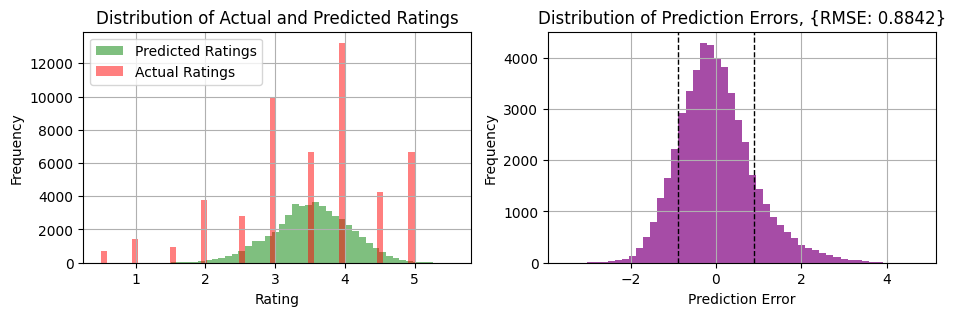

Total number of parameters in the model: 320355

 *******    Training with 0.02 learning rate...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.9112
Epoch 2/20 - Test RMSE: 0.8980
Epoch 3/20 - Test RMSE: 0.8913
Epoch 4/20 - Test RMSE: 0.8876
Epoch 5/20 - Test RMSE: 0.8860
Epoch 6/20 - Test RMSE: 0.8843
Epoch 7/20 - Test RMSE: 0.8836
Epoch 8/20 - Test RMSE: 0.8829
Epoch 9/20 - Test RMSE: 0.8817
Error increased at epoch 10. Stopping training.
RMSE error: 0.8839


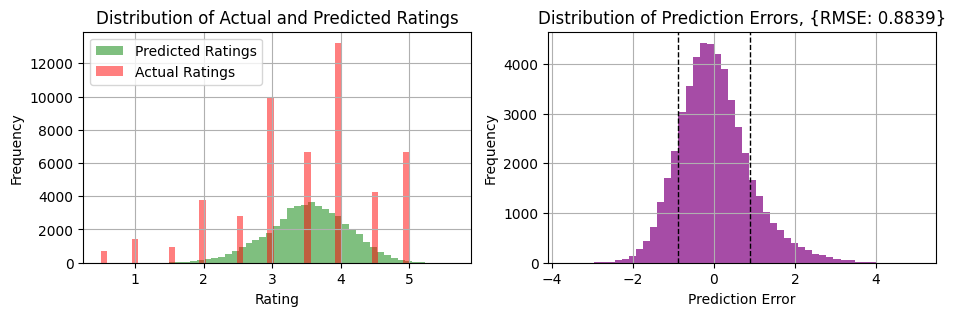

Total number of parameters in the model: 320355

 *******    Training with 0.05 learning rate...
Number of users: 610, Number of items: 9724
Epoch 1/20 - Test RMSE: 0.8998
Epoch 2/20 - Test RMSE: 0.8910
Epoch 3/20 - Test RMSE: 0.8877
Error increased at epoch 4. Stopping training.
RMSE error: 0.8909


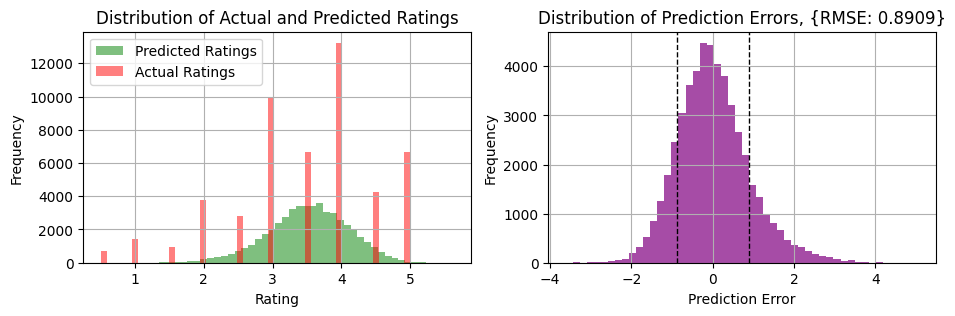

Total number of parameters in the model: 320355
(0, [0.9831370944609702, 0.9603138151228324, 0.9463716910914282, 0.9367044231199633, 0.9295382716586897, 0.9239608068179311, 0.919513254969915, 0.9157448078804464, 0.912651993555893, 0.9100311159765971, 0.9076755372154303, 0.9056688369808831, 0.903979724088477, 0.9023924620331409, 0.9009302873820743, 0.8996375776377585, 0.8984047916733751, 0.8973836258477478, 0.8963297952762024, 0.8954016011409295])
(1, [0.95292142655718, 0.9296695947588811, 0.9176956296170018, 0.9100797734468257, 0.9046457630093939, 0.9009371887744939, 0.8980031605186064, 0.8956191354738415, 0.8933946215904387, 0.8919545412329541, 0.8905498279565858, 0.889221640269528, 0.8882957320146024, 0.8875994539172984, 0.8865344112300615, 0.8857905904222502, 0.8852147065100741, 0.8849470072126124, 0.8842592913314309, 0.8839087498419393])
(2, [0.9302168502398753, 0.9102186841732987, 0.9013426983534941, 0.8968730933586379, 0.8927170226728827, 0.8896413896931207, 0.8876195125302753, 0

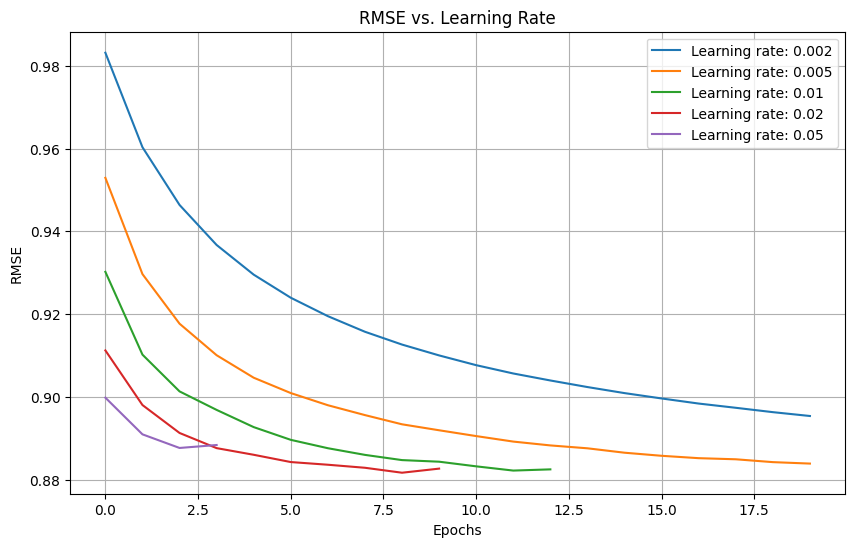

In [47]:
# 2.3. Plot RMSE vs. learning rate
use_bias = True # False
learning_rates = [0.002 , 0.005, 0.01, 0.02, 0.05]
n_factors = 30
n_epochs = 20

errors_list = []
num_params_list = []

# Train and evaluate the model with different numbers of factors
for rate in learning_rates:
    
    print(f"\n *******    Training with {rate} learning rate...")
    
    mf = MatrixFactorization(n_factors=n_factors, learning_rate=rate, reg_param=0.01, n_epochs=n_epochs, use_bias=True, verbose=True)
    mf.build_maps(ratings)
    mf.fit(train_data, test_data)
    errors_list.append(mf.get_errors())

    # Evaluate the model on the evaluation set
    predict_errors_plot(eval_data, mf)
    
    # Calculate the number of parameters in the model
    num_params = mf.calculate_model_parameters()
    print(f"Total number of parameters in the model: {num_params}")    
    num_params_list.append(num_params)

# Plot RMSE vs. number of factors
plt.figure(figsize=(10, 6))
for i in enumerate(errors_list):
    print(i)
    plt.plot(i[1], label=f'Learning rate: {learning_rates[i[0]]}')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('RMSE vs. Learning Rate')
plt.legend()
plt.grid()
plt.show()


In [16]:
# 2.4. Plot RMSE vs. regularization parameter
use_bias = True # False
reg_parameters = [0.001, 0.01, 0.1, 0.2]
n_factors = 30


